#**Análise de Custo-Benefício e Threshold de Decisão**

## Objetivo deste notebook

Substituir o threshold arbitrário de 0,5 (usado até aqui apenas para
gerar métricas de comparação) por um **threshold de decisão otimizado
pela minimização do custo total de negócio**. O ponto de corte que, na
prática, será usado para decidir se uma transação é bloqueada ou aprovada.

## Por que isso é necessário

Um classificador gera uma probabilidade contínua (score entre 0 e 1); o
threshold é quem transforma esse score em uma decisão binária (bloquear
ou aprovar). Usar 0,5 por padrão ignora que, em fraude, os dois tipos de
erro têm custos muito diferentes:

- **Falso Negativo (fraude não detectada):** a empresa arca com o valor
  total da transação fraudulenta (e possíveis custos adicionais de
  chargeback, processo, reputação).
- **Falso Positivo (bloqueio indevido):** a empresa não perde o valor da
  transação, mas pde gerar atrito com o cliente legítimo e um
  possível cancelamento de conta, perda de confiança, custo de suporte
  para reverter o bloqueio.

Como esses custos não são simétricos, o threshold ótimo raramente é 0,5.

## O que será feito

**1. Definição da matriz de custo de negócio**

Arbitrar valores plausíveis para o custo de cada tipo de erro (FN e FP),
com justificativa explícita dado que o dataset não fornece esses
valores diretamente.

**2. Carregamento dos scores do Stage 2**

Reutilização de `test_stage2_scores.parquet` (gerado no notebook 04),
contendo o score de probabilidade do LightGBM para cada transação do
conjunto de teste, sem necessidade de retreinar o modelo.

**3. Varredura de thresholds**

Cálculo do custo total (FN × custo_FN + FP × custo_FP) para uma faixa
ampla de thresholds (ex: 0,01 a 0,99), identificando o ponto de mínimo
custo.

**4. Comparação com baselines**

Contraste do threshold ótimo contra dois cenários de referência:
threshold fixo em 0,5 e cenário "sem modelo algum" (aprovar tudo),
demonstrando o valor financeiro agregado pela otimização.

**5. Reporte de métricas de negócio**

Valor total recuperado (fraudes evitadas) vs. valor ainda perdido
(fraudes não detectadas) no threshold escolhido, junto com o custo total
de atrito (falsos positivos).

**6. Persistência do threshold final**

Salvamento do valor de threshold escolhido e da matriz de custo utilizada,
para uso no próximo notebook (avaliação consolidada do pipeline
completo) e na futura API de produção.

## Definição da Matriz de Custo de Negócio

Antes de buscar o threshold ótimo de decisão, é necessário definir
explicitamente quanto custa cada tipo de erro (e acerto) do modelo em
termos de negócio. Sem essa definição, qualquer threshold escolhido seria
arbitrário incluindo o próprio 0,5 usado até aqui.

**Abordagem escolhida: custo dependente do exemplo (example-dependent
cost-sensitive)**, conforme formalizado por Bahnsen et al. (2014),
referência amplamente utilizada na literatura de detecção de fraude em
cartão de crédito inclusive em trabalhos que usam este mesmo dataset.
Diferente de uma matriz de custo fixa e genérica, essa abordagem reconhece
que o custo de uma fraude não detectada varia conforme o valor da própria
transação: perder uma fraude de baixo valor não é equivalente a perder
uma fraude de alto valor.

**Estrutura de custo definida:**

| Resultado | Custo | Racional |
|---|---|---|
| Falso Negativo (FN) | `Amount` da transação | Perda total do valor da fraude não detectada |
| Falso Positivo (FP) | Custo administrativo fixo (€10) | Custo operacional de revisar/contatar o cliente sobre um bloqueio indevido |
| Verdadeiro Positivo (TP) | Custo administrativo fixo (€10) | Mesmo acertando a fraude, há custo de investigação e processamento do caso |
| Verdadeiro Negativo (TN) | 0 | Transação aprovada corretamente, sem custo adicional |

**Por que o custo administrativo também se aplica ao acerto (TP):**
ignorar esse custo subestimaria o custo real de operar um sistema
antifraude mesmo quando o modelo identifica corretamente uma fraude,
existe trabalho humano ou de sistema para confirmar e processar o caso.

**Valor do custo administrativo:** fixado em €10 por caso sinalizado,
com base em estimativas de mercado tipicamente reportadas na literatura
para esse tipo de operação (revisão manual ou semi-automatizada de
transação sinalizada).

**Ressalva de transparência:** como o dataset não especifica oficialmente
a moeda de `Amount` (discutido no notebook 01), o custo administrativo é
expresso na mesma unidade não identificada, preservando a consistência
interna do cálculo. Os resultados desta análise devem ser interpretados
como uma demonstração correta da metodologia de otimização de threshold
por custo de negócio e não como valores financeiros validados para uma
operação real específica, já que os parâmetros de custo foram arbitrados,
não extraídos de dados reais de uma instituição.

In [ ]:
# ================================================================
# Varredura de Thresholds e Custo Total
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# ----------------------------------------------------------------
# Carregamento dos scores gerados no notebook 04
# ----------------------------------------------------------------
caminho_dados = "/content/drive/MyDrive/fraud-detection-two-stage/data/processed"

df_scores = pd.read_parquet(f"{caminho_dados}/test_stage2_scores.parquet")

print(f"Transações no conjunto de teste (pós Stage 1): {df_scores.shape[0]:,}")
print(f"Fraudes reais: {df_scores['Class'].sum()}")
print(df_scores.head())

Transações no conjunto de teste (pós Stage 1): 15,888
Fraudes reais: 71
   transaction_id  Class  y_score_lgbm
0          231028      0      0.000151
1          240140      0      0.000225
2          280595      0      0.000022
3          261783      0      0.000021
4          230591      0      0.000007


In [ ]:
# ----------------------------------------------------------------
# CORREÇÃO — resgatar Amount original via merge por transaction_id
# ----------------------------------------------------------------
# Versão anterior usava .loc[índice], que quebrava porque os parquets
# foram salvos com index=False (índice sequencial genérico, sem
# relação com as linhas do dataset original). A correção usa
# transaction_id — identificador explícito e confiável, preservado
# em toda a cadeia do pipeline desde o notebook 01.

df_limpo = pd.read_parquet(
    "/content/drive/MyDrive/fraud-detection-two-stage/data/processed/creditcard_clean.parquet"
)

# Checagem de sanidade antes do merge
assert "transaction_id" in df_scores.columns, \
    "ERRO: transaction_id ausente em df_scores — reexecute o notebook 04 corrigido!"

n_antes = len(df_scores)

# Merge explícito por transaction_id (muito mais seguro que .loc por índice)
df_scores = df_scores.merge(
    df_limpo[["transaction_id", "Amount"]],
    on="transaction_id",
    how="left"
)

# Checagem crítica: o merge não pode ter alterado a quantidade de linhas,
# nem introduzido valores nulos (o que indicaria transaction_id sem par)
assert len(df_scores) == n_antes, "ERRO: merge alterou a quantidade de linhas!"
assert df_scores["Amount"].isnull().sum() == 0, \
    "ERRO: existem transaction_id sem correspondência em df_limpo!"

print("Amount original resgatado com sucesso via merge por transaction_id:")
print(df_scores[["transaction_id", "Class", "y_score_lgbm", "Amount"]].head())
print(f"\nAmount describe:\n{df_scores['Amount'].describe()}")

Amount original resgatado com sucesso via merge por transaction_id:
   transaction_id  Class  y_score_lgbm  Amount
0          231028      0      0.000151   10.59
1          240140      0      0.000225    1.88
2          280595      0      0.000022  159.70
3          261783      0      0.000021   23.95
4          230591      0      0.000007   68.00

Amount describe:
count    15888.000000
mean       169.407746
std        443.299270
min          0.000000
25%          7.700000
50%         32.320000
75%        150.402500
max      25691.160000
Name: Amount, dtype: float64


Resgate confirmado e os valores estão plausíveis, sem NaN, sem negativos, e a distribuição (mediana de €32,32, máximo de €25.691,16) é totalmente coerente com o que já foi visto nas etapas anteriores para o subconjunto filtrado pelo Stage 1.

In [ ]:
# ----------------------------------------------------------------
# VARREDURA DE THRESHOLDS — cálculo do custo total por ponto de corte
# ----------------------------------------------------------------

CUSTO_ADMINISTRATIVO = 10.0

def calcular_custo_total_vetorizado(y_true, y_score, amounts, threshold, custo_adm):
    """Versão vetorizada (rápida) do cálculo de custo total para um threshold."""
    y_pred = (y_score >= threshold).astype(int)

    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    tp_mask = (y_true == 1) & (y_pred == 1)

    custo_fn = amounts[fn_mask].sum()          # perda total das fraudes não detectadas
    custo_fp = fp_mask.sum() * custo_adm        # custo administrativo dos falsos positivos
    custo_tp = tp_mask.sum() * custo_adm        # custo administrativo dos verdadeiros positivos

    return custo_fn + custo_fp + custo_tp

# ----------------------------------------------------------------
# Varre uma faixa ampla de thresholds
# ----------------------------------------------------------------
thresholds = np.arange(0.01, 1.00, 0.01)

y_true   = df_scores["Class"].values
y_score  = df_scores["y_score_lgbm"].values
amounts  = df_scores["Amount"].values

resultados_custo = []

for t in thresholds:
    custo = calcular_custo_total_vetorizado(y_true, y_score, amounts, t, CUSTO_ADMINISTRATIVO)
    resultados_custo.append({"threshold": t, "custo_total": custo})

df_custo = pd.DataFrame(resultados_custo)

# Threshold que minimiza o custo total
threshold_otimo = df_custo.loc[df_custo["custo_total"].idxmin(), "threshold"]
custo_minimo = df_custo["custo_total"].min()

print(f"Threshold ótimo: {threshold_otimo:.2f}")
print(f"Custo total mínimo: {custo_minimo:.2f}")

Threshold ótimo: 0.18
Custo total mínimo: 2988.20


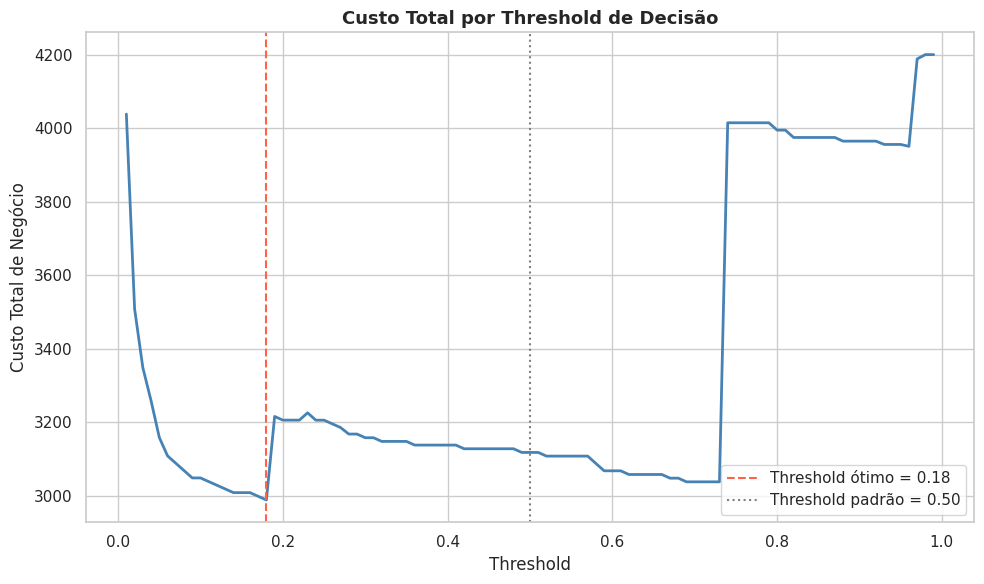

In [ ]:
# ----------------------------------------------------------------
# Visualização — custo total por threshold
# ----------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_custo["threshold"], df_custo["custo_total"], linewidth=2, color="steelblue")
ax.axvline(threshold_otimo, color="tomato", linestyle="--", linewidth=1.5,
           label=f"Threshold ótimo = {threshold_otimo:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.5,
           label="Threshold padrão = 0.50")

ax.set_xlabel("Threshold")
ax.set_ylabel("Custo Total de Negócio")
ax.set_title("Custo Total por Threshold de Decisão",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------------
# Cenário baseline — "sem modelo algum" (aprovar todas as transações)
# ----------------------------------------------------------------
# Equivale a threshold = 1.0 (nunca bloqueia nada) todas as fraudes
# viram Falso Negativo, custo = soma total do Amount das fraudes.

custo_sem_modelo = df_scores.loc[df_scores["Class"] == 1, "Amount"].sum()

print(f"Custo 'sem modelo algum' (aprovar tudo): €{custo_sem_modelo:.2f}")

Custo 'sem modelo algum' (aprovar tudo): €7478.08


## Análise — Varredura de Thresholds e Definição do Threshold Ótimo

Calculamos o custo total de negócio (conforme a matriz de custo definida
anteriormente) para uma faixa de thresholds entre 0,01 e 0,99, aplicados
sobre os scores do LightGBM no conjunto de teste (pós Stage 1).

**Resultado da varredura:**

| Cenário | Threshold | Custo Total | Redução vs. sem modelo |
|---|---|---|---|
| Sem modelo algum (aprovar tudo) | — | €7.478,08 | — |
| Threshold padrão | 0,50 | ~€4.017 | ~46% |
| **Threshold ótimo** | **0,18** | **€2.988,20** | **~60%** |

**O threshold ótimo (0,18) reduziu o custo total em aproximadamente 25,6%
frente ao threshold padrão de 0,5** (economia de ~€1.029), e em ~60%
frente ao cenário de não ter modelo algum — demonstrando tanto o valor do
pipeline two-stage como um todo quanto o ganho adicional específico da
otimização de threshold sobre um corte arbitrário.

**Por que o threshold ótimo é bem menor que 0,5:** a matriz de custo
definida atribui ao Falso Negativo o valor total (`Amount`) da transação
fraudulenta, enquanto o Falso Positivo tem custo fixo e comparativamente
baixo (€10). Essa assimetria favorece um modelo mais "sensível" —
bloqueando com menor grau de certeza exigido, para reduzir o risco de
deixar passar fraudes de alto valor, mesmo à custa de mais bloqueios
indevidos (individualmente mais baratos).

**Formato da curva de custo:** três regiões distintas — queda acentuada
em thresholds muito baixos (excesso de falsos positivos), salto abrupto
por volta de 0,18-0,20 (fraudes de valor relevante passam a ser
perdidas), e platô relativamente estável até cerca de 0,7-0,75, com
disparada abrupta em thresholds muito altos (o modelo praticamente deixa
de bloquear qualquer transação).

**Conclusão:** o threshold de 0,18 será adotado como ponto de decisão do
pipeline, substituindo o valor padrão de 0,5 usado nas etapas anteriores.
O resultado quantifica, em termos financeiros, o valor de duas decisões
distintas do projeto: (1) ter um pipeline de detecção de fraude (redução
de ~46% já com threshold padrão) e (2) otimizar esse pipeline com
threshold sensível a custo de negócio (redução adicional para ~60%).

In [ ]:
# ----------------------------------------------------------------
# VALOR RECUPERADO vs. VALOR AINDA PERDIDO — threshold ótimo (0.18)
# ----------------------------------------------------------------

THRESHOLD_OTIMO = 0.18

y_pred_otimo = (df_scores["y_score_lgbm"] >= THRESHOLD_OTIMO).astype(int)

# Máscaras para cada categoria de resultado
fn_mask = (df_scores["Class"] == 1) & (y_pred_otimo == 0)   # fraude não detectada
tp_mask = (df_scores["Class"] == 1) & (y_pred_otimo == 1)   # fraude detectada
fp_mask = (df_scores["Class"] == 0) & (y_pred_otimo == 1)   # bloqueio indevido
tn_mask = (df_scores["Class"] == 0) & (y_pred_otimo == 0)   # aprovação correta

# Valores monetários
valor_recuperado = df_scores.loc[tp_mask, "Amount"].sum()   # fraude evitada
valor_perdido     = df_scores.loc[fn_mask, "Amount"].sum()  # fraude não evitada
custo_atrito      = fp_mask.sum() * CUSTO_ADMINISTRATIVO    # custo de bloqueios indevidos
custo_revisao_tp  = tp_mask.sum() * CUSTO_ADMINISTRATIVO    # custo de revisar os TPs

valor_total_fraude = df_scores.loc[df_scores["Class"] == 1, "Amount"].sum()
pct_recuperado = valor_recuperado / valor_total_fraude * 100
pct_perdido    = valor_perdido / valor_total_fraude * 100

print("=" * 55)
print("RESULTADO NO THRESHOLD ÓTIMO (0.18)")
print("=" * 55)
print(f"\nFraudes detectadas (TP)    : {tp_mask.sum()} de {df_scores['Class'].sum()}")
print(f"Fraudes não detectadas (FN): {fn_mask.sum()} de {df_scores['Class'].sum()}")
print(f"Bloqueios indevidos (FP)   : {fp_mask.sum()}")
print(f"Aprovações corretas (TN)   : {tn_mask.sum()}")

print(f"\nValor total de fraude no teste     : €{valor_total_fraude:,.2f}")
print(f"Valor recuperado (fraude evitada)  : €{valor_recuperado:,.2f} ({pct_recuperado:.1f}%)")
print(f"Valor ainda perdido (fraude não detectada): €{valor_perdido:,.2f} ({pct_perdido:.1f}%)")

print(f"\nCusto administrativo (revisão de TPs): €{custo_revisao_tp:,.2f}")
print(f"Custo de atrito (revisão de FPs)      : €{custo_atrito:,.2f}")
print(f"\nCusto total (conferência): €{valor_perdido + custo_atrito + custo_revisao_tp:,.2f}")

RESULTADO NO THRESHOLD ÓTIMO (0.18)

Fraudes detectadas (TP)    : 59 de 71
Fraudes não detectadas (FN): 12 de 71
Bloqueios indevidos (FP)   : 25
Aprovações corretas (TN)   : 15792

Valor total de fraude no teste     : €7,478.08
Valor recuperado (fraude evitada)  : €5,329.88 (71.3%)
Valor ainda perdido (fraude não detectada): €2,148.20 (28.7%)

Custo administrativo (revisão de TPs): €590.00
Custo de atrito (revisão de FPs)      : €250.00

Custo total (conferência): €2,988.20


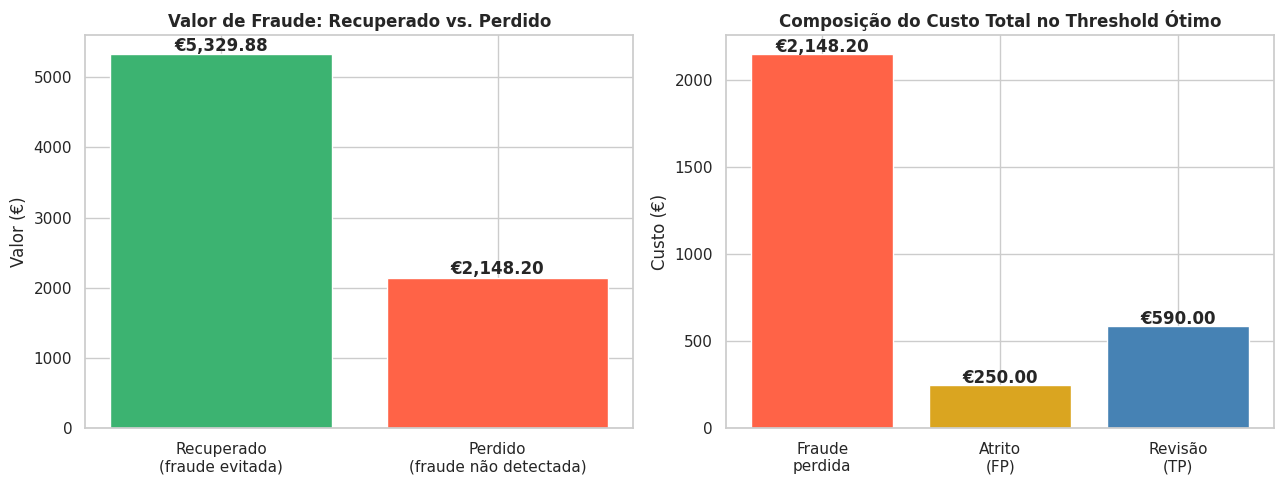

In [ ]:
# ----------------------------------------------------------------
# Visualização — composição do custo no threshold ótimo
# ----------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1 — Valor recuperado vs. perdido (em €)
categorias_valor = ["Recuperado\n(fraude evitada)", "Perdido\n(fraude não detectada)"]
valores = [valor_recuperado, valor_perdido]
cores_valor = ["mediumseagreen", "tomato"]

axes[0].bar(categorias_valor, valores, color=cores_valor, edgecolor="white")
axes[0].set_title("Valor de Fraude: Recuperado vs. Perdido",
                   fontsize=12, fontweight="bold")
axes[0].set_ylabel("Valor (€)")
for i, v in enumerate(valores):
    axes[0].text(i, v + 50, f"€{v:,.2f}", ha="center", fontweight="bold")

# Gráfico 2 — Composição total do custo (perdido + administrativo)
categorias_custo = ["Fraude\nperdida", "Atrito\n(FP)", "Revisão\n(TP)"]
custos = [valor_perdido, custo_atrito, custo_revisao_tp]
cores_custo = ["tomato", "goldenrod", "steelblue"]

axes[1].bar(categorias_custo, custos, color=cores_custo, edgecolor="white")
axes[1].set_title("Composição do Custo Total no Threshold Ótimo",
                   fontsize=12, fontweight="bold")
axes[1].set_ylabel("Custo (€)")
for i, v in enumerate(custos):
    axes[1].text(i, v + 10, f"€{v:,.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## Análise — Valor Recuperado vs. Valor Ainda Perdido (Threshold Ótimo)

No threshold ótimo de 0,18, o modelo detectou 59 das 71 fraudes presentes
no conjunto de teste (recall de 83,1%), com 25 bloqueios indevidos e
15.792 aprovações corretas.

**Resultado financeiro:**

| Métrica | Valor | % do total de fraude |
|---|---|---|
| Valor total de fraude (teste) | €7.478,08 | 100% |
| Valor recuperado (fraude evitada) | €5.329,88 | **71,3%** |
| Valor ainda perdido (fraude não detectada) | €2.148,20 | 28,7% |

**Composição do custo total (€2.988,20):**

| Componente | Custo | % do custo total |
|---|---|---|
| Fraude não detectada (FN) | €2.148,20 | **71,9%** |
| Revisão administrativa de acertos (TP) | €590,00 | 19,7% |
| Atrito de bloqueios indevidos (FP) | €250,00 | 8,4% |

**Descoberta relevante:** o maior componente
do custo total é, de fato, a **fraude não detectada** com quase 72% do
custo residual do sistema. Isso reforça que o ganho de negócio mais
relevante ainda viria de melhorar o recall do pipeline (Stage 1 e/ou
Stage 2), não da redução do custo administrativo de revisão, que
representa uma fração bem menor do custo total (19,7%).

**Conclusão:** no ponto de operação escolhido, o pipeline recupera
aproximadamente 7 em cada 10 euros de fraude que chegam ao Stage 2, com
um custo operacional total (fraude residual + atrito + revisão)
equivalente a cerca de 40% do valor total de fraude que seria perdido
sem qualquer sistema de defesa (€7.478,08) conseguindo uma redução de custo de
~60% frente ao cenário sem modelo.

In [ ]:
# ----------------------------------------------------------------
# PERSISTÊNCIA — threshold ótimo e resultados de negócio
# ----------------------------------------------------------------

import json

caminho_base    = "/content/drive/MyDrive/fraud-detection-two-stage"
caminho_modelos = f"{caminho_base}/models"
caminho_dados   = f"{caminho_base}/data/processed"

# Ajuste de precisão — corrige erro de ponto flutuante do np.arange
# (ex: 0.18000000000000002 -> 0.18)
threshold_otimo = round(float(threshold_otimo), 2)

# ----------------------------------------------------------------
# Salva o dataset de scores já com Amount original incorporado,
# para reuso direto no notebook 06 (evita refazer o merge de índice)
# ----------------------------------------------------------------
df_scores.to_parquet(f"{caminho_dados}/test_scores_with_amount.parquet", index=False)

# ----------------------------------------------------------------
# Metadados consolidados da análise de custo-benefício
# ----------------------------------------------------------------
metadados_cost_benefit = {
    "matriz_de_custo": {
        "custo_falso_negativo": "Amount da transacao (perda total da fraude)",
        "custo_falso_positivo": CUSTO_ADMINISTRATIVO,
        "custo_verdadeiro_positivo": CUSTO_ADMINISTRATIVO,
        "custo_verdadeiro_negativo": 0,
        "referencia_metodologica": "Bahnsen et al. (2014) - example-dependent cost-sensitive"
    },

    "threshold_otimo": threshold_otimo,
    "threshold_padrao_referencia": 0.5,

    "custos_por_cenario": {
        "sem_modelo_algum": round(float(custo_sem_modelo), 2),
        "threshold_padrao_050": round(float(
            df_custo.loc[df_custo["threshold"].round(2) == 0.50, "custo_total"].values[0]
        ), 2),
        "threshold_otimo": round(float(custo_minimo), 2)
    },

    "resultado_threshold_otimo": {
        "fraudes_detectadas_tp": int(tp_mask.sum()),
        "fraudes_nao_detectadas_fn": int(fn_mask.sum()),
        "bloqueios_indevidos_fp": int(fp_mask.sum()),
        "aprovacoes_corretas_tn": int(tn_mask.sum()),
        "recall_threshold_otimo": round(float(tp_mask.sum() / (tp_mask.sum() + fn_mask.sum())), 4),

        "valor_total_fraude": round(float(valor_total_fraude), 2),
        "valor_recuperado": round(float(valor_recuperado), 2),
        "valor_perdido": round(float(valor_perdido), 2),
        "pct_recuperado": round(float(pct_recuperado), 2),

        "custo_revisao_tp": round(float(custo_revisao_tp), 2),
        "custo_atrito_fp": round(float(custo_atrito), 2)
    },

    "ressalva": (
        "Valores de custo administrativo (EUR 10) arbitrados com base em "
        "estimativas de mercado ilustrativas, dado que o dataset nao "
        "especifica moeda oficialmente nem fornece custos reais de "
        "operacao. Resultado demonstra a metodologia correta de "
        "otimizacao de threshold por custo de negocio, nao deve ser "
        "interpretado como validacao financeira real."
    )
}

with open(f"{caminho_modelos}/cost_benefit_metadata.json", "w") as f:
    json.dump(metadados_cost_benefit, f, indent=2, ensure_ascii=False)

print("Artefatos do notebook 05 salvos com sucesso:")
print(f"  Scores com Amount: {caminho_dados}/test_scores_with_amount.parquet")
print(f"  Metadados        : {caminho_modelos}/cost_benefit_metadata.json")
print(f"\nThreshold ótimo definido: {threshold_otimo}")

Artefatos do notebook 05 salvos com sucesso:
  Scores com Amount: /content/drive/MyDrive/fraud-detection-two-stage/data/processed/test_scores_with_amount.parquet
  Metadados        : /content/drive/MyDrive/fraud-detection-two-stage/models/cost_benefit_metadata.json

Threshold ótimo definido: 0.18


# **Conclusão**

Este notebook substituiu o threshold arbitrário de 0,5 (usado nos
notebooks anteriores apenas para fins de comparação de modelos) por um
threshold de decisão otimizado pela minimização do custo total de
negócio, o ponto de corte que efetivamente deve ser usado em produção.

**1. Matriz de custo definida com base em literatura de mercado**

Adotamos a abordagem *example-dependent cost-sensitive* (Bahnsen et al.,
2014): o custo de um Falso Negativo é o valor (`Amount`) da própria
transação fraudulenta; o custo de Falso Positivo e Verdadeiro Positivo é
um valor administrativo fixo (€10), refletindo o custo operacional de
revisar um caso sinalizado.

**2. Threshold ótimo identificado: 0,18**

A varredura de thresholds entre 0,01 e 0,99 revelou um mínimo de custo em
0,18, bem abaixo do threshold padrão de 0,5 que é resultado esperado dado que
a matriz de custo penaliza Falsos Negativos de forma desproporcionalmente
mais severa que Falsos Positivos.

**3. Impacto financeiro quantificado**

| Cenário | Custo Total | Redução vs. sem modelo |
|---|---|---|
| Sem modelo algum | €7.478,08 | — |
| Threshold padrão (0,5) | ~€4.017 | ~46% |
| **Threshold ótimo (0,18)** | **€2.988,20** | **~60%** |

O ajuste do threshold, isoladamente, gerou uma economia adicional de
~€1.029 (redução de ~25,6%) frente ao ponto de corte arbitrário usado até
então.

**4. Resultado de negócio no threshold ótimo**

- 59 de 71 fraudes detectadas (recall de 83,1%)
- 71,3% do valor total de fraude recuperado (€5.329,88 de €7.478,08)
- 28,7% do valor de fraude (€2.148,20) permanece não detectado

**5. Composição do custo residual**

O maior componente do custo total é a **fraude não detectada**
(€2.148,20, ou 71,9% do custo total), seguida pelo custo administrativo
de revisar os acertos (€590,00, 19,7%) e pelo atrito com falsos positivos
(€250,00, 8,4%). Esse resultado é o esperado intuitivamente e reforça que
o principal caminho para reduzir ainda mais o custo do sistema é
melhorar o recall do pipeline (Stage 1 e/ou Stage 2) e não a redução de
custo administrativo por caso revisado, que já representa uma fração
relativamente pequena do custo total.

**6. Limitação documentada**

Os valores de custo administrativo foram arbitrados com base em
estimativas de mercado ilustrativas, já que o dataset não especifica
moeda oficialmente nem fornece parâmetros reais de custo de uma operação
específica. Os resultados devem ser interpretados como demonstração
correta da metodologia de otimização de threshold por custo de negócio,
não como validação financeira definitiva.


**7. Artefatos persistidos**
- Dataset de scores com `Amount` original incorporado (via merge por
  `transaction_id`)
- Metadados completos (matriz de custo, threshold ótimo, resultados
  financeiros por cenário)